# Corpus Preparation Pipeline - Data Exploration

## 1. Setup
Set environment variables, imports and constants.

In [ ]:
import sys
from pathlib import Path

# Calculate the path to the target directory (two levels up)
target_dir = str(Path().resolve().parent)

# Check if the path is already in sys.path
if target_dir not in sys.path:
    sys.path.insert(1, target_dir)
    print(f"Added '{target_dir}' to sys.path")
else:
    print(f"'{target_dir}' already in sys.path")

import logging
import importlib
import dotenv
import os
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pandas as pd
import numpy as np
from utils import utils as corpus_prep_utils
from utils.utils import dataset_names, data_step_names, filters, partition_rules, print_df
from utils.database.database_helper import DatabaseHelper
import corpus_prep_pipeline as corpus_prep


# Reload the variables in your '.env' file (override the existing variables)
dotenv.load_dotenv("../.env", override=True)

input_data_root_path = os.environ.get("INPUT_DATA_ROOT_PATH")

# supress info logging for task calls outside prefect flow
# logging.getLogger("prefect").setLevel(logging.WARNING)
# logging.getLogger("prefect.task_runs").setLevel(logging.WARNING)

def format_number(x, p=None):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.1f}K'
    else:
        return f'{x:.0f}'
    
# #######################################
#      SEQUENCE PLOTS                   #
# #######################################

def plot_seq_count_by_family(sequence_df, threshold=0):
    # Explore sequence count by family
    # Aggregate by family_name and count occurrences
    family_sequence_counts = sequence_df['family_name'].value_counts().reset_index()
    family_sequence_counts.columns = ['family_name', 'sequence_count']
    total_sequences = family_sequence_counts['sequence_count'].sum()
    grouped_data = family_sequence_counts[family_sequence_counts['sequence_count'] / total_sequences >= threshold]
    other_sequence_counts = family_sequence_counts[family_sequence_counts['sequence_count'] / total_sequences < threshold]['sequence_count'].sum()
    other_data = {'family_name':['Other'], 'sequence_count' : [other_sequence_counts]}
    grouped_data = pd.concat([grouped_data, pd.DataFrame(other_data)], ignore_index=True)
    plt.figure(figsize=(8, 8))
    sns.set_palette("viridis")
    plt.pie(grouped_data['sequence_count'], labels=grouped_data['family_name'], autopct='%1.1f%%', startangle=140)
    plt.title('Secuencias por familia - #Seqs '+str(total_sequences))

    # 2. Show the pie chart
    plt.show()

def seq_plot_sequence_length_distr(db_helper, bins, long_tail=-1):
    #Explore sequence length distribution
    query = """SELECT
        families.family_type as family_type,
        LENGTH(sequences.sequence) as sequence_length,
        sequences.sequence as sequence,
        FROM
        `intense-linker-434400-f6.protein_input.testGroupDataset_sequences` AS sequences
        INNER JOIN
        `intense-linker-434400-f6.protein_input.family_types` AS families
        ON
        sequences.family_name = families.family_name
        """
    sequence_df = db_helper.set_query(query).execute()
    #sequence_df['sequence_length'] = sequence_df['sequence'].apply(len)
    group_column = 'sequence_length'
    if long_tail > -1:
        # Create a new column where lengths greater than X are grouped
        sequence_df['length_group'] = sequence_df['sequence_length'].apply(lambda x: x if x <= long_tail else long_tail)
        group_column = 'length_group'
        
    # 4. Create a histogram using Seaborn
    plt.figure(figsize=(10, 6))
    ts_sl_histplot = sns.histplot(data=sequence_df, x=group_column, bins=bins, kde=False, hue='family_type',
    multiple='stack',
    edgecolor='white')

    #ts_sl_histplot = sns.histplot(sequence_df['length_group'], kde=False, bins=bins)

    """    # Add labels to each segment
    for container in ts_sl_histplot.containers:
        # Optional: Filter out zero-height bars
        heights = container.datavalues
        for i, height in enumerate(heights):
            if height > 0:
                ts_sl_histplot.bar_label(
                    [container],
                    labels=[format_number(int(height))],
                    label_type='center'
                )"""
  
    # Add labels to each bar
    for p in ts_sl_histplot.patches:
        height = p.get_height()
        if height > 0:
            ts_sl_histplot.text(p.get_x() + p.get_width() / 1.5, height*1.02 if height > 120000 else height*1.05, format_number(int(height)), ha="center")


    # 5. Set custom x-axis ticks
    plt.xticks(np.arange(0, long_tail + 500, 1000))
    # Format y-axis
    formatter = FuncFormatter(format_number)
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.title('Distribution of Sequence Lengths')
    plt.xlabel('Sequence Length')
    plt.ylabel('# of Sequences')

    # 5. Show the histogram
    plt.show()

def seq_plot_aminoacid_frequencies(letter_frequencies):
    df = pd.DataFrame(list(letter_frequencies.items()), columns=['letter', 'probability'])
    # Sort DataFrame by 'y' column in descending order
    sorted_df = df.sort_values(by='probability', ascending=False)

    # Create the bar plot using Seaborn
    plt.figure(figsize=(10, 6))
    sns.barplot(x="letter", y="probability", data=sorted_df, order=sorted_df["letter"], hue=sorted_df["letter"], dodge=False, palette="pastel")  # Assign 'letters' to 'hue'

    # Add labels and title
    plt.xlabel("Aminoacid", fontsize=12)
    plt.ylabel("Relative frequency", fontsize=12)
    plt.title("Relative Freq Distribution of Aminoacids", fontsize=14)
    plt.legend([],[], frameon=False) # Remove legend

    # Show the plot
    plt.show()

# #######################################
#      PATTERMS PLOTS                   #
# #######################################

def plot_mr_scatter(db_helper, patterns_table_override=""):

    query = f"""
        SELECT 
            t1.type, 
            COUNT (DISTINCT t1.pattern) as unique_patterns, 
            SUM(ARRAY_LENGTH(t1.starting_positions)) as instances_sum, 
            100 * COUNT (DISTINCT t1.protein_id) 
                / (SELECT COUNT(sequence) 
                    FROM `{db_helper.BQ_INPUT_DATASET_NAME}.{db_helper.sequences_table_name}`) as unique_affected_proteins 
        FROM ({db_helper.CHAIN_QUERY_WILDCARD}) as t1 
        GROUP BY 1
    """

    db_helper.select_all_patterns_positions(patterns_table_override).set_query(query, chain_query=True)
    print(db_helper.query)
    grouped_mr_df = db_helper.execute()
    # Step 2: Create the scatterplot
    plt.figure(figsize=(10, 6))
    mr_scatter = sns.scatterplot(data=grouped_mr_df, 
                    x='unique_affected_proteins', 
                    y='unique_patterns', 
                    size='instances_sum', 
                    hue='type',
                    sizes=(20, 500),  # Adjust the range of circle sizes
                    legend='full')

    plt.title('MRs by Type, Affected Proteins, and Instances')
    plt.xlabel('% Affected Sequences')
    plt.ylabel('Number of Unique Patterns')
    formatter = FuncFormatter(format_number)
    # Format y-axis
    plt.gca().yaxis.set_major_formatter(formatter)

    # Get the current legend labels
    handles, labels = plt.gca().get_legend_handles_labels()
    # Format the labels
    formatted_labels = []
    for label in labels:
        try:
            label = formatter(float(label), None)
        except:
            pass
        formatted_labels.append(label)
        
    # Create a new legend with formatted labels
    plt.legend(handles, formatted_labels, bbox_to_anchor=(1.05, 1), loc='upper left')

    # Adjust layout to prevent cutting off labels
    plt.tight_layout()
    # Redraw the canvas to update the legend
    plt.gcf().canvas.draw()
    plt.show()

def plot_mr_stacked(db_helper, patterns_table_override=""):
    source = f"{db_helper.BQ_STAGE_DATASET_NAME}.{patterns_table_override}" if len(patterns_table_override) > 0 else f"{db_helper.BQ_INPUT_DATASET_NAME}.{db_helper.patterns_table_name}"
    query = f'''
        SELECT
            t1.type,
            CASE 
                WHEN t1.length <= 12 THEN LPAD(CAST(t1.length AS STRING), 2, '0')
                ELSE '13+'
            END AS length_group,
            COUNT(*) AS pattern_count
        FROM 
            (SELECT pattern, 
            type, 
            LENGTH(pattern) as length, 
            FROM 
                `{source}`) as t1
        GROUP BY 1, 2;
    '''

    data = db_helper.set_query(query).execute()

    sorted_data = data.sort_values(by='length_group', ascending=True)
    # Create the stacked bar chart
    plt.figure(figsize=(12, 6))
    chart = sns.barplot(x='length_group', y='pattern_count', hue='type', data=sorted_data, order=sorted_data['length_group'])

    # Customize the chart
    plt.title('Pattern Quantity by Length and Type')
    plt.xlabel('Pattern Length')
    plt.ylabel('Unique Quantity of Patterns')

    formatter = FuncFormatter(format_number)
    # Format y-axis
    plt.gca().yaxis.set_major_formatter(formatter)

    # Rotate x-axis labels if there are many pattern lengths
    plt.xticks(rotation=45)

    # Adjust layout to prevent cutting off labels
    plt.tight_layout()

    # Show the plot
    plt.show()


'/home/mgiordano/tesis/thesis_exp' already in sys.path


## 2. TestGroup dataset exploration

In [6]:
test_dataset_name = dataset_names.TEST_GROUP
test_db_helper = DatabaseHelper(test_dataset_name)

### 2.1. Sequence dataset

In [3]:
corpus_prep.load_sequence_dataset(input_data_root_path, test_dataset_name, test_db_helper)
test_sequence_df = test_db_helper.select_sequences().execute()
print(len(test_sequence_df))
print_df(test_sequence_df)

14:57:07.794 | INFO    | Task run 'load_sequence_dataset' - Created task run 'load_sequence_dataset' for task 'load_sequence_dataset'

14:57:08.406 | INFO    | Task run 'load_sequence_dataset' - Finished in state Completed()

483
| id   | family_name   | name                   | sequence                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   |
|:---

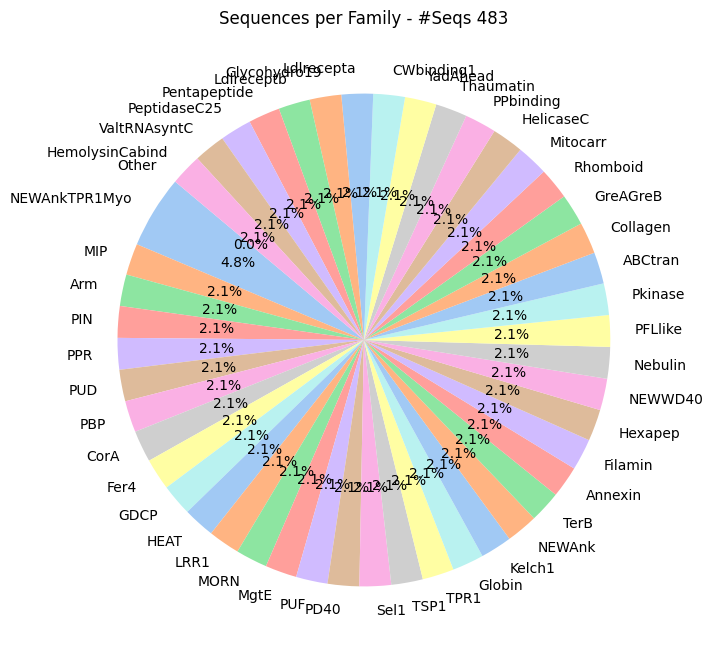

In [4]:
plot_seq_count_by_family(test_sequence_df)

AttributeError: 'list' object has no attribute 'patches'

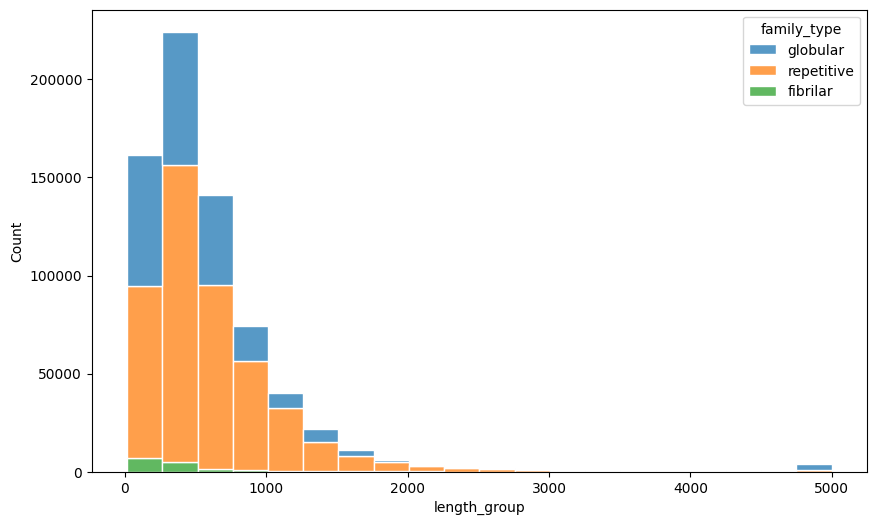

In [7]:
seq_plot_sequence_length_distr(test_db_helper, bins=20, long_tail=5000)

14:57:21.604 | INFO    | Task run 'count_aminoacid_frequency' - Created task run 'count_aminoacid_frequency' for task 'count_aminoacid_frequency'

14:57:21.691 | INFO    | Task run 'count_aminoacid_frequency' - {'A': 0.08949698004915467, 'R': 0.05366099299302736, 'N': 0.043561110014334395, 'D': 0.060238792134108134, 'C': 0.017164078750475667, 'E': 0.05983536904629065, 'Q': 0.04035089225170167, 'G': 0.07646155034634301, 'H': 0.02246580202512668, 'I': 0.05051658183337196, 'L': 0.09398613483486834, 'K': 0.04881991593921759, 'M': 0.02004812465487298, 'F': 0.03435676906746321, 'P': 0.04907169772452211, 'S': 0.06918276782572122, 'T': 0.06009573430154874, 'W': 0.013232849511743618, 'Y': 0.030800351350036767, 'V': 0.0666535053460712, 'U': 0.0, 'O': 0.0, 'X': 0.0, 'B': 0.0, 'Z': 0.0, 'J': 0.0}

14:57:21.734 | INFO    | Task run 'count_aminoacid_frequency' - Finished in state Completed()

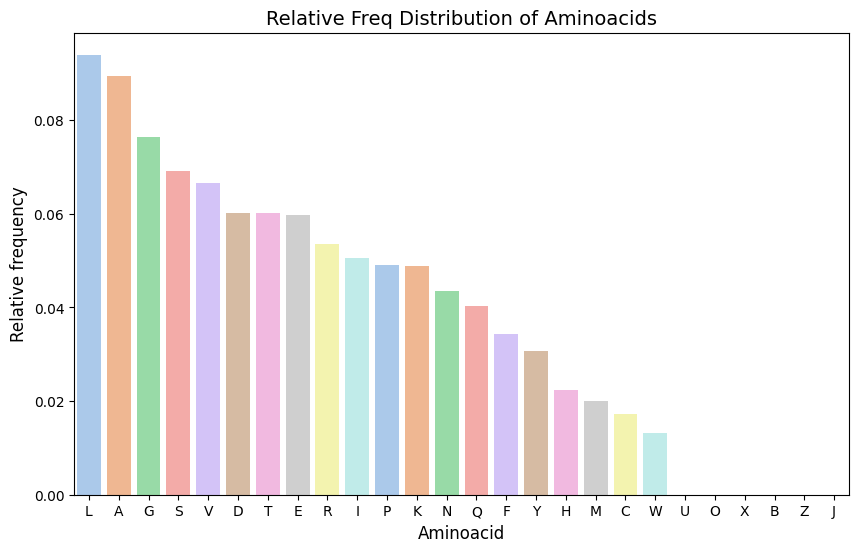

In [6]:
letter_probs = corpus_prep.count_aminoacid_frequency(test_sequence_df)

seq_plot_aminoacid_frequencies(letter_probs)

### 2.2 MR Dataset

In [7]:
corpus_prep.load_patterns_dataset(input_data_root_path, test_dataset_name, test_db_helper)
mr_test_df = test_db_helper.preview_patterns()
print_df(mr_test_df)

14:57:41.742 | INFO    | Task run 'load_patterns_dataset' - Created task run 'load_patterns_dataset' for task 'load_patterns_dataset'

14:57:42.275 | INFO    | Task run 'load_patterns_dataset' - Finished in state Completed()

| pattern_id   | type   | pattern   | instances   |
|:-------------|:-------|:----------|:------------|
| 108497       | NE     | YP        | 512         |
| 66657        | NE     | NS        | 1024        |
| 104858       | NE     | V         | 23296       |
| 10516        | NE     | CK        | 257         |
| 87217        | NE     | SLL       | 257         |
| 108319       | NE     | YN        | 513         |
| 89723        | NE     | SS        | 2050        |
| 30632        | NE     | GGAAP     | 3           |
| 31917        | NE     | GIWA      | 3           |
| 37667        | NE     | HIDS      | 3           |
-


In [8]:
corpus_prep.load_positions_dataset(input_data_root_path, test_dataset_name, test_db_helper)
positions_test_df = test_db_helper.preview_positions()
print_df(positions_test_df)

14:57:49.780 | INFO    | Task run 'load_positions_dataset' - Created task run 'load_positions_dataset' for task 'load_positions_dataset'

14:57:50.186 | INFO    | Task run 'load_positions_dataset' - Finished in state Completed()

| pattern_id   | protein_id   | position   |
|:-------------|:-------------|:-----------|
| 22329        | 75           | 0          |
| 22091        | 75           | 0          |
| 22099        | 75           | 0          |
| 3837         | 345          | 0          |
| 9655         | 345          | 0          |
| 4012         | 345          | 0          |
| 3831         | 345          | 0          |
| 23857        | 382          | 0          |
| 23991        | 382          | 0          |
| 23864        | 382          | 0          |
-


In [9]:
full_mr_test_df = test_db_helper.select_all_patterns_positions(limit=100).execute()
print_df(full_mr_test_df)


| pattern_id   | type   | pattern   | instances   | protein_id   | starting_positions            |
|:-------------|:-------|:----------|:------------|:-------------|:------------------------------|
| 22329        | NE     | EN        | 936         | 75           | [0 2]                         |
| 22091        | SMR    | ENEN      | 3           | 75           | [0]                           |
| 22099        | NE     | ENE       | 52          | 75           | [0]                           |
| 3837         | NE     | AIN       | 76          | 345          | [0]                           |
| 9655         | NE     | A         | 31280       | 345          | [  0  39  45  46  59  92 103] |
| 4012         | NE     | AI        | 1609        | 345          | [0]                           |
| 3831         | SMR    | AINS      | 3           | 345          | [0]                           |
| 23857        | NN     | ETML      | 8           | 382          | [0]                           |
| 23991   


        SELECT 
            t1.type, 
            COUNT (DISTINCT t1.pattern) as unique_patterns, 
            SUM(ARRAY_LENGTH(t1.starting_positions)) as instances_sum, 
            100 * COUNT (DISTINCT t1.protein_id) 
                / (SELECT COUNT(sequence) 
                    FROM `protein_input.testGroupDataset_sequences`) as unique_affected_proteins 
        FROM (
            SELECT 
                patterns.pattern_id,
                patterns.type,
                patterns.pattern,
                patterns.instances,
                positions.protein_id,
                positions.starting_positions
            FROM `protein_input.testGroupDataset_patterns` as patterns 
            INNER JOIN (
            SELECT
                protein_id,
                pattern_id,
                ARRAY_AGG(position) AS starting_positions
            FROM
                `protein_input.testGroupDataset_positions`
            GROUP BY
            1,
            2
        ) as positions 
 

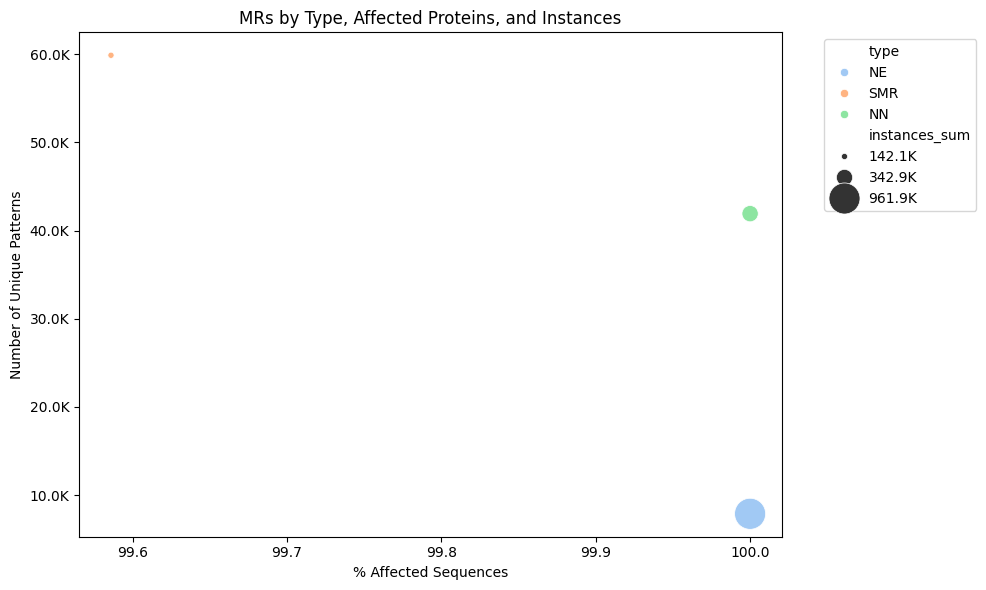

In [10]:
plot_mr_scatter(test_db_helper)

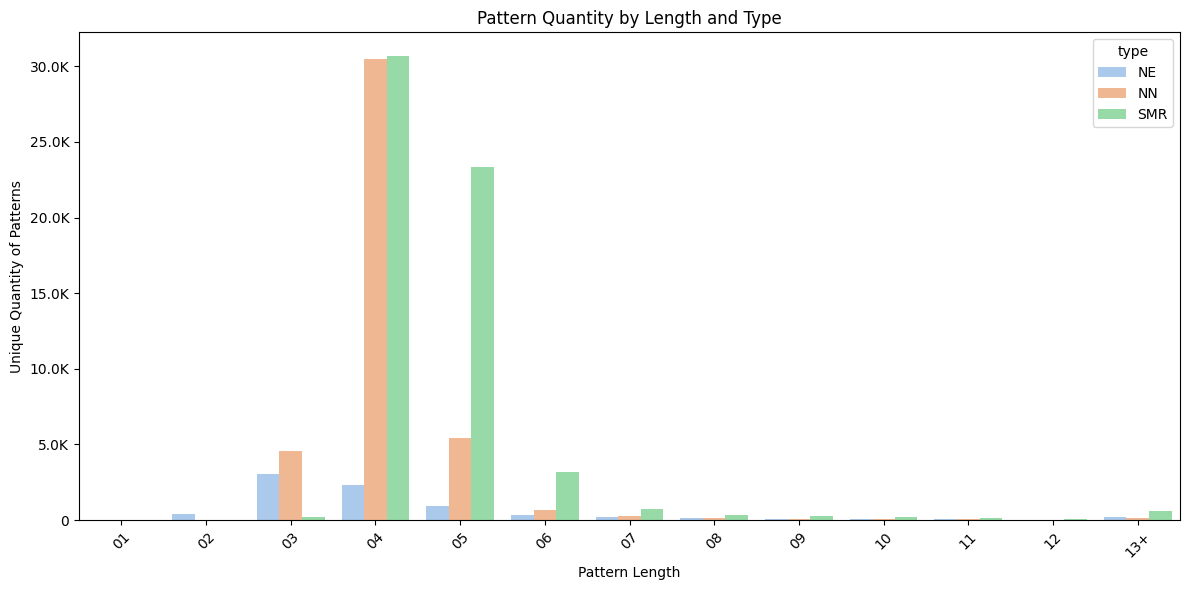

In [11]:
plot_mr_stacked(test_db_helper)

#### 2.2.1 Filter NE


        SELECT 
            t1.type, 
            COUNT (DISTINCT t1.pattern) as unique_patterns, 
            SUM(ARRAY_LENGTH(t1.starting_positions)) as instances_sum, 
            100 * COUNT (DISTINCT t1.protein_id) 
                / (SELECT COUNT(sequence) 
                    FROM `protein_input.testGroupDataset_sequences`) as unique_affected_proteins 
        FROM (
            SELECT 
                patterns.pattern_id,
                patterns.type,
                patterns.pattern,
                patterns.instances,
                positions.protein_id,
                positions.starting_positions
            FROM `stage_results.20240913_22_41_32-testGroupDataset-filter_drop_ne-partition_use_all-s1_filtered_mrs` as patterns 
            INNER JOIN (
            SELECT
                protein_id,
                pattern_id,
                ARRAY_AGG(position) AS starting_positions
            FROM
                `protein_input.testGroupDataset_positions`
            GROUP

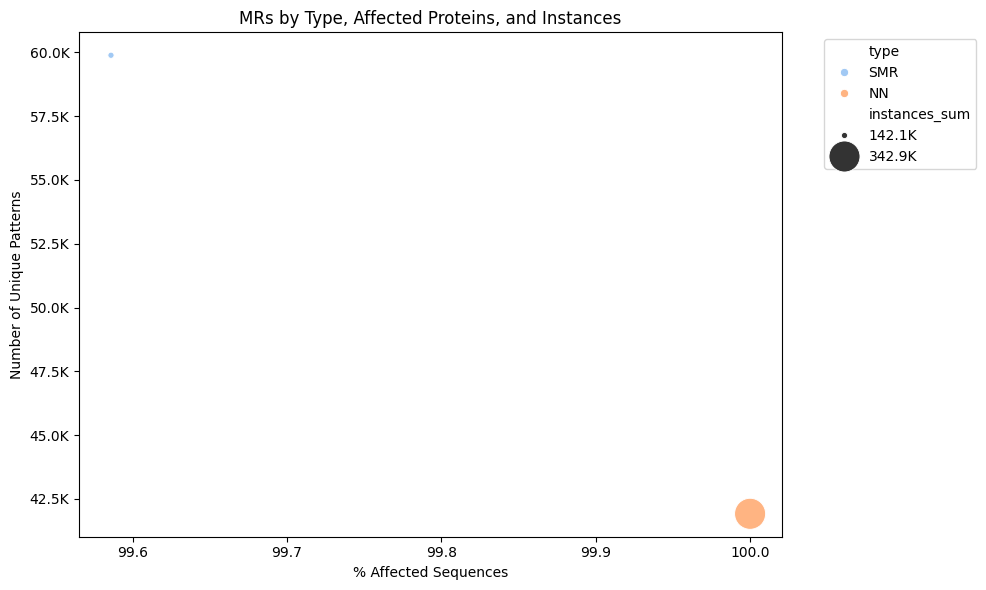

In [16]:
patterns_filtered_ne_table_path = corpus_prep_utils.get_stage_run_table_name(dataset_names.TEST_GROUP, "20240913_22_41_32", data_step_names.S1_FILTERED_MR, filters.MR_FILTER_DROP_NE.name, partition_rules.PARTITION_RULE_USE_ALL["name"])
plot_mr_scatter(test_db_helper, patterns_filtered_ne_table_path)


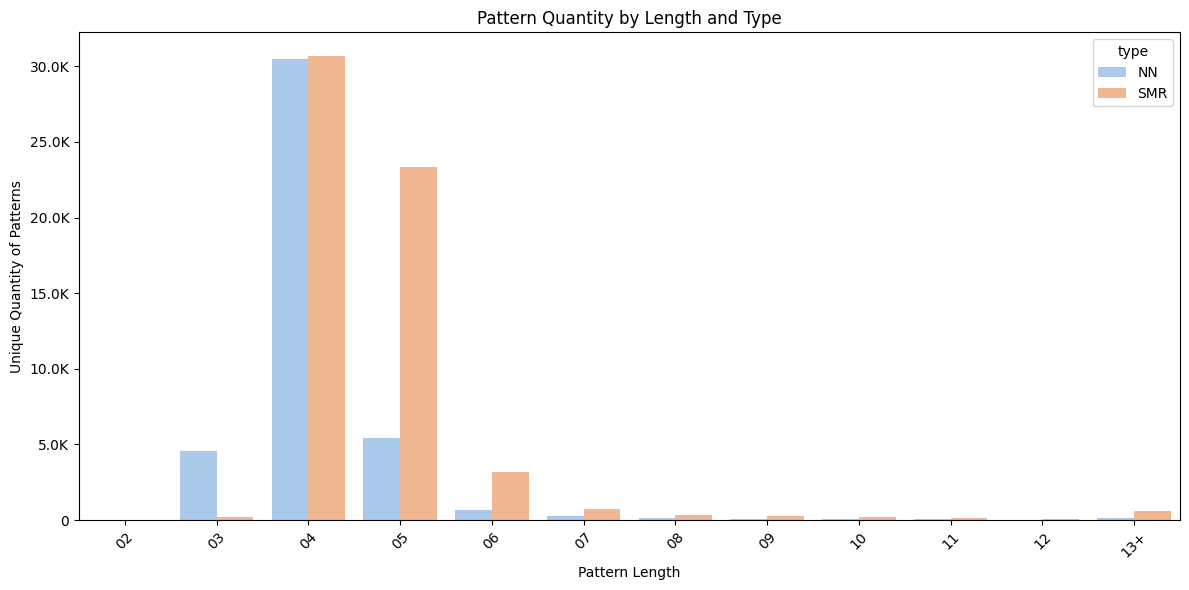

In [19]:
plot_mr_stacked(test_db_helper, patterns_filtered_ne_table_path)

## 3. Family Group Dataset Exploration

In [2]:
family_dataset_name = dataset_names.FAMILY
family_db_helper = DatabaseHelper(family_dataset_name)

### 3.1 Sequence Dataset

In [5]:
corpus_prep.load_sequence_dataset(input_data_root_path, dataset_names.FAMILY, family_db_helper)
family_sequence_df = family_db_helper.select_sequences().execute()
print(len(family_sequence_df))
print_df(family_sequence_df)

19:07:57.831 | INFO    | Task run 'load_sequence_dataset' - Created task run 'load_sequence_dataset' for task 'load_sequence_dataset'

19:07:59.085 | INFO    | Task run 'load_sequence_dataset' - Finished in state Completed()

696114
| id   | family_name   | name                   | sequence                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
|:-----|:--------------|:-----------------------|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

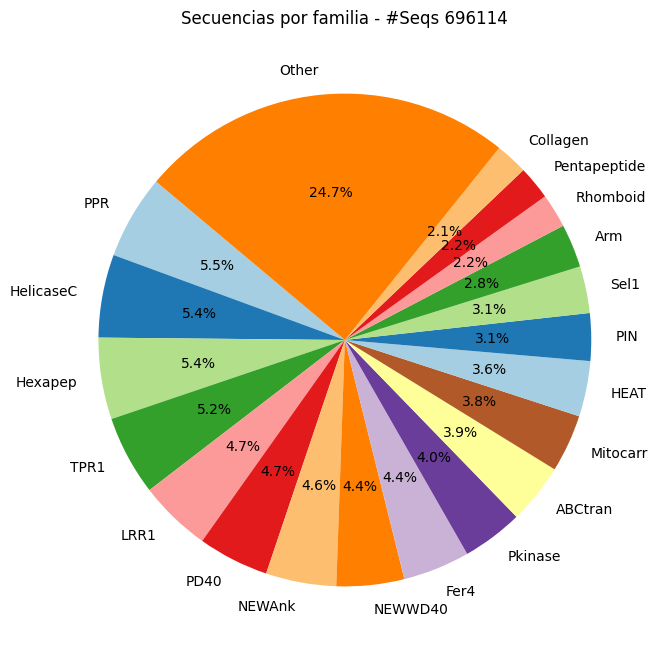

In [16]:
plot_seq_count_by_family(family_sequence_df, 0.02)

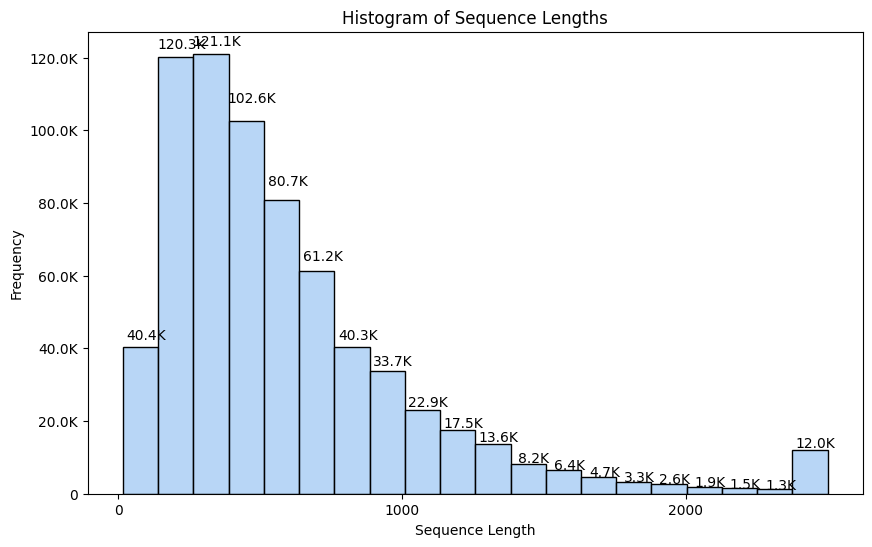

In [20]:
seq_plot_sequence_length_distr(family_sequence_df, bins=20, long_tail=2500)

{'A': 0.08637007251627421, 'R': 0.055173534772037014, 'N': 0.043110174570132186, 'D': 0.05860910470871743, 'C': 0.017195426015887964, 'E': 0.06078316997939946, 'Q': 0.03916611323239624, 'G': 0.07423417656716816, 'H': 0.023215384341934077, 'I': 0.05272086069302245, 'L': 0.10036949704560404, 'K': 0.04977688484770939, 'M': 0.020746006302095752, 'F': 0.03522106213261615, 'P': 0.04705700954336389, 'S': 0.07370667022600443, 'T': 0.055870506789332586, 'W': 0.012526007206139798, 'Y': 0.028747037809080417, 'V': 0.06540130070108437, 'U': 0.0, 'O': 0.0, 'X': 0.0, 'B': 0.0, 'Z': 0.0, 'J': 0.0}


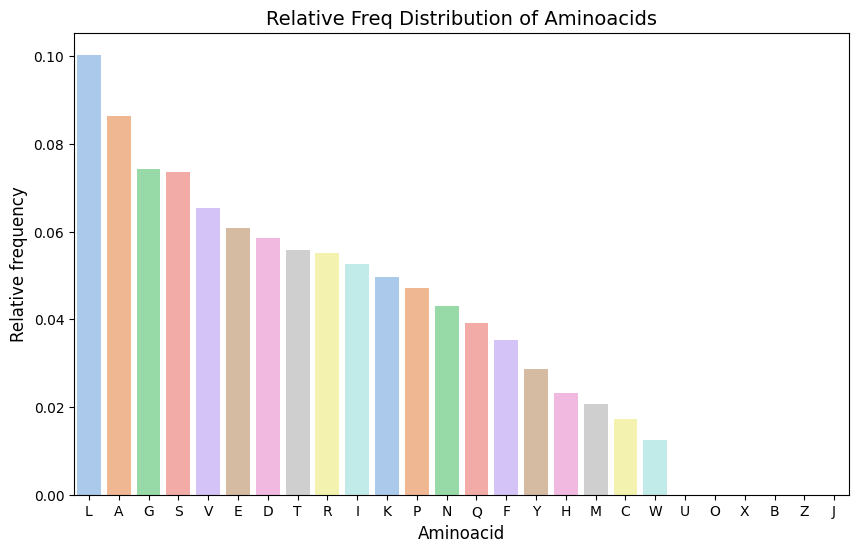

In [27]:
letter_probs = corpus_prep.count_aminoacid_frequency(family_sequence_df)

seq_plot_aminoacid_frequencies(letter_probs)

### 3.2 MR Dataset

In [33]:
corpus_prep.load_patterns_dataset(input_data_root_path, family_dataset_name, family_db_helper)
patterns_family_df = family_db_helper.preview_patterns()
print_df(patterns_family_df)

corpus_prep.load_positions_dataset(input_data_root_path, family_dataset_name, family_db_helper)
positions_family_df = family_db_helper.preview_positions()
print_df(positions_family_df)

#mr_family_df = family_db_helper.select_all_patterns_positions(limit=100).execute()
#print(mr_family_df.head(10))

| pattern_id   | type   | pattern   | instances   |
|:-------------|:-------|:----------|:------------|
| 33888471     | NE     | GVGALV    | 256         |
| 24356623     | NE     | FGYLAPEYA | 256         |
| 67449360     | NE     | PPPIA     | 256         |
| 53210100     | NE     | LMWM      | 256         |
| 31661661     | NE     | GNYSK     | 256         |
| 52434589     | NE     | LLKFR     | 256         |
| 62969913     | NE     | NPSPT     | 256         |
| 11216883     | NE     | DAYAH     | 256         |
| 5617122      | NE     | ANLQGADL  | 256         |
| 84755299     | NE     | SSMGR     | 256         |
-
| pattern_id   | protein_id   | position   |
|:-------------|:-------------|:-----------|
| 11405        | 149046       | 101        |
| 22218        | 346291       | 721        |
| 22575        | 424811       | 935        |
| 28461        | 302085       | 780        |
| 45232        | 216888       | 1444       |
| 48233        | 418895       | 395        |
| 60605       


        SELECT 
            t1.type, 
            COUNT (DISTINCT t1.pattern) as unique_patterns, 
            SUM(ARRAY_LENGTH(t1.starting_positions)) as instances_sum, 
            100 * COUNT (DISTINCT t1.protein_id) 
                / (SELECT COUNT(sequence) 
                    FROM `protein_input.familyDataset_sequences`) as unique_affected_proteins 
        FROM (
            SELECT 
                patterns.pattern_id,
                patterns.type,
                patterns.pattern,
                patterns.instances,
                positions.protein_id,
                positions.starting_positions
            FROM `protein_input.familyDataset_patterns` as patterns 
            INNER JOIN (
            SELECT
                protein_id,
                pattern_id,
                ARRAY_AGG(position) AS starting_positions
            FROM
                `protein_input.familyDataset_positions`
            GROUP BY
            1,
            2
        ) as positions 
          

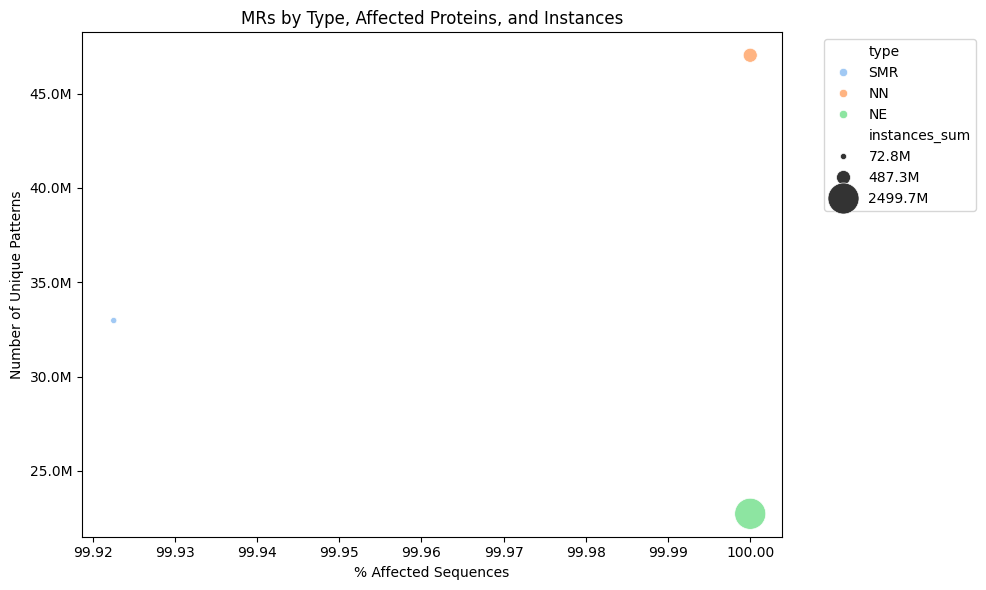

In [34]:
plot_mr_scatter(family_db_helper)

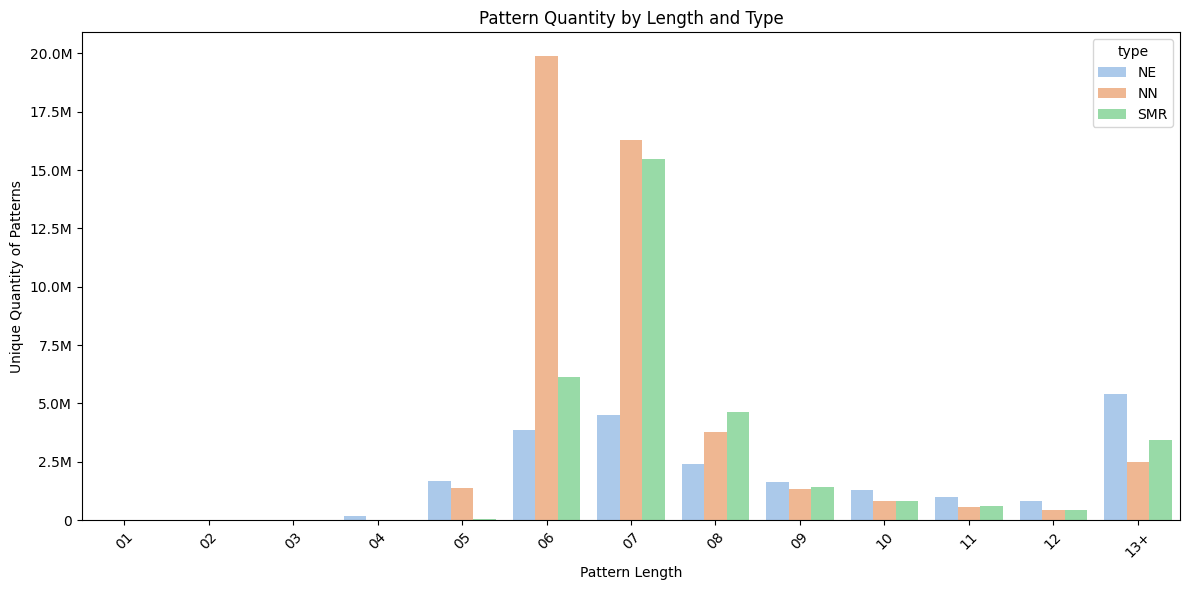

In [35]:
plot_mr_stacked(family_db_helper)


        SELECT 
            t1.type, 
            COUNT (DISTINCT t1.pattern) as unique_patterns, 
            SUM(ARRAY_LENGTH(t1.starting_positions)) as instances_sum, 
            100 * COUNT (DISTINCT t1.protein_id) 
                / (SELECT COUNT(sequence) 
                    FROM `protein_input.familyDataset_sequences`) as unique_affected_proteins 
        FROM (
            SELECT 
                patterns.pattern_id,
                patterns.type,
                patterns.pattern,
                patterns.instances,
                positions.protein_id,
                positions.starting_positions
            FROM `stage_results.20240914_14_29_16-familyDataset-filter_keep_length_7plus-partition_use_all-s1_filtered_mrs` as patterns 
            INNER JOIN (
            SELECT
                protein_id,
                pattern_id,
                ARRAY_AGG(position) AS starting_positions
            FROM
                `protein_input.familyDataset_positions`
            GROU

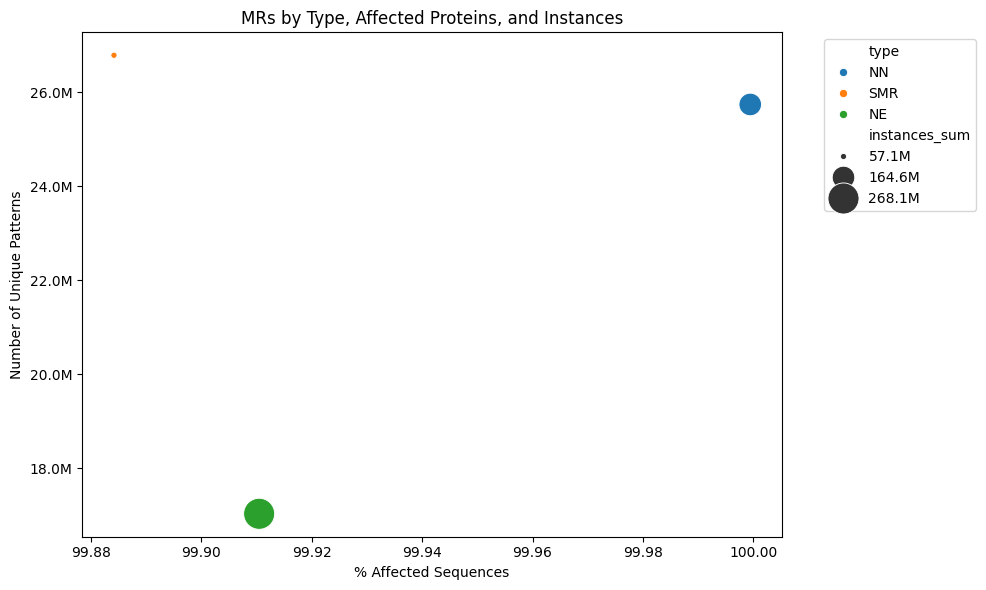

In [9]:
test_table = "20240914_14_29_16-familyDataset-filter_keep_length_7plus-partition_use_all-s1_filtered_mrs"
plot_mr_scatter(family_db_helper, test_table)